In [7]:
import astropy.units as u
import numpy as np
from astropy.io import ascii

import naima
from naima.models import ExponentialCutoffPowerLaw, InverseCompton

In [2]:
data = ascii.read("/Users/vdk/data/sgr1900+14/naima/SED1_1.dat")
data

energy,energy_edge_lo,energy_edge_hi,flux,flux_error
MeV,MeV,MeV,1 / (MeV s cm2),1 / (MeV s cm2)
float64,float64,float64,float64,float64
1732.05080757,1000.0,3000.0,1.90552116e-13,9.24686816e-14
5477.22557505,3000.0,10000.0,2.10724925e-14,5.89361975e-15
17320.50807569,10000.0,30000.0,1.84678315e-16,6.32129498e-16
54772.25575052,30000.0,100000.0,1.01716139e-16,6.4883228e-17
173205.08075689,100000.0,300000.0,5.68423751e-21,1.40862125e-17


In [2]:
from astropy.table import QTable
import astropy.units as u

rows_mev = [
    (1_732.05080757, 1_000, 3_000,   1.90552116e-13, 9.24686816e-14),
    (5_477.22557505, 3_000, 10_000,  2.10724925e-14, 5.89361975e-15),
    (17_320.50807569,10_000,30_000,  1.84678315e-16, 6.32129498e-16),
    (54_772.25575052,30_000,100_000, 1.01716139e-16, 6.48832280e-17),
    (173_205.08075689,100_000,300_000,5.68423751e-21, 1.40862125e-17),
]

data = QTable(names=["energy","energy_edge_lo","energy_edge_hi","flux","flux_error"])
for r in rows_mev:
    E, Elo, Ehi, F, dF = r
    data.add_row((E/1000, Elo/1000, Ehi/1000, F*1000, dF*1000))

data["energy"].unit = data["energy_edge_lo"].unit = data["energy_edge_hi"].unit = u.GeV
data["flux"].unit = data["flux_error"].unit = 1/(u.cm**2*u.s*u.GeV)
data.meta["cl"] = 0.95  # if you later mark ULs
data

energy,energy_edge_lo,energy_edge_hi,flux,flux_error
GeV,GeV,GeV,1 / (GeV s cm2),1 / (GeV s cm2)
float64,float64,float64,float64,float64
1.7320508075699999,1.0,3.0,1.90552116e-10,9.246868159999999e-11
5.47722557505,3.0,10.0,2.1072492500000002e-11,5.89361975e-12
17.32050807569,10.0,30.0,1.84678315e-13,6.32129498e-13
54.77225575052,30.0,100.0,1.01716139e-13,6.4883228e-14
173.20508075689,100.0,300.0,5.68423751e-18,1.4086212499999999e-14


Burning in the 32 walkers with 300 steps...


/Users/vdk/miniforge3/envs/naima/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]



Progress of the run: 0 percent (0 of 300 steps)
                           log10(norm/1eV) -----index----- log10(Ecut/TeV)
  Last ensemble median :      35.3            2.43            0.291     
  Last ensemble std    :      3.57            0.359          0.0287     
  Last ensemble lnprob :  avg: -inf, max: -3.699

Progress of the run: 5 percent (15 of 300 steps)
                           log10(norm/1eV) -----index----- log10(Ecut/TeV)
  Last ensemble median :      34.6            2.49             0.3      
  Last ensemble std    :      2.77            0.537          0.0498     
  Last ensemble lnprob :  avg: -7409.829, max: -1.742

Progress of the run: 10 percent (30 of 300 steps)
                           log10(norm/1eV) -----index----- log10(Ecut/TeV)
  Last ensemble median :      34.6            2.54            0.311     
  Last ensemble std    :       2.4            0.662           0.27      
  Last ensemble lnprob :  avg: -6.628, max: -1.579

Progress of the run: 15 percent 

INFO: Plotting chain of parameter log10(Ecut/TeV)... [naima.analysis]
INFO: -----------------log10(Ecut/TeV)------------------
          log10(Ecut/TeV) = $0.6^{+1.6}_{-1.2}$
                 Ecut/TeV = $4^{+160}_{-4}$ [naima.plot]
INFO: Plotting corner plot... [naima.analysis]
INFO: Plotting Model output 0... [naima.analysis]
INFO: Plotting Model output 1... [naima.analysis]
INFO: Saving results table in magnetar_IC_12p5kpc_3_results.ecsv [naima.analysis]


/Users/vdk/miniforge3/envs/naima/lib/python3.12/site-packages/naima/analysis.py:153: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  f.clf()


label,median,unc_lo,unc_hi
bytes72,float64,float64,float64
log10(norm/1eV),34.61229847564655,0.6568472071484877,0.607831712884007
norm/1eV,4.0954202905650403e+34,3.192911857830132e+34,1.2505424527977991e+35
index,3.191069118612588,0.5545768805396754,0.4272398776973567
log10(Ecut/TeV),0.6401309940898259,1.202937417093069,1.5824391555292034
Ecut/TeV,4.366475164322653,4.092826346065683,162.57726937069307
blob1,nan,nan,nan


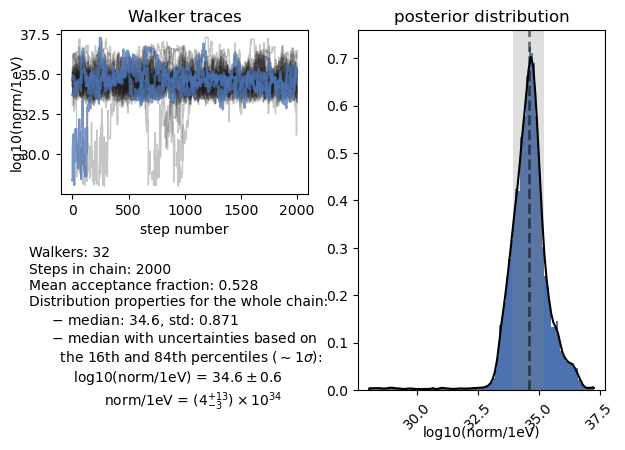

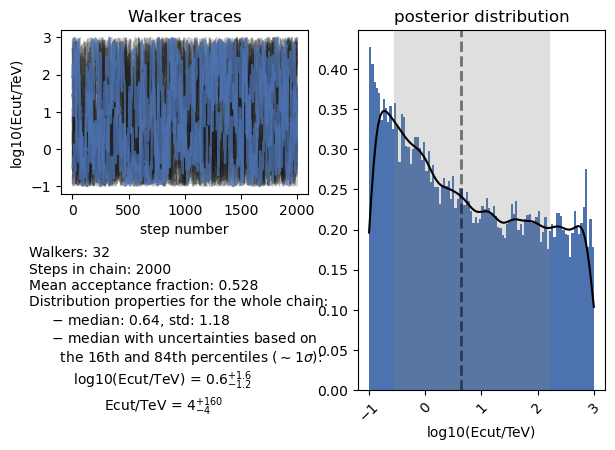

In [6]:
import numpy as np, naima
from fit_module import electron_ic, lnprior
# 'data' from step 1

p0     = np.array([33.5, 2.4, np.log10(2.0)])   # inside prior box
labels = ["log10(norm/1eV)", "index", "log10(Ecut/TeV)"]

sampler, pos = naima.run_sampler(
    data_table=data,
    p0=p0,
    labels=labels,
    model=electron_ic,
    prior=lnprior,
    nwalkers=32,
    nburn=300,
    nrun=2000,
    threads=1,
    prefit=False,
)

naima.save_diagnostic_plots("magnetar_IC_12p5kpc_3", sampler, sed=True)
naima.save_results_table("magnetar_IC_12p5kpc_3", sampler)

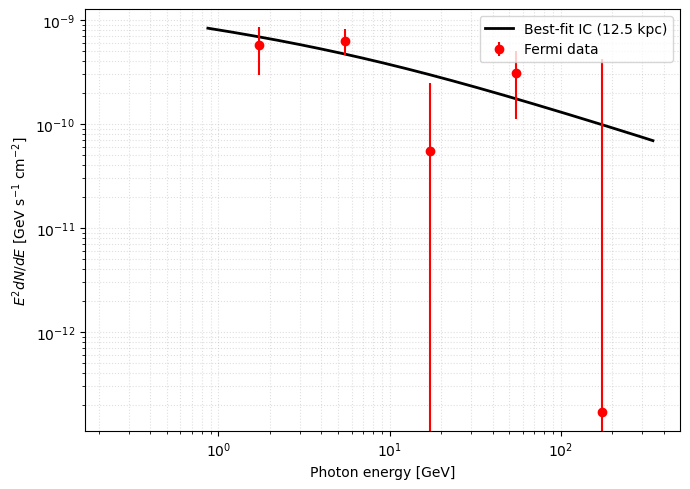

In [7]:
import numpy as np, astropy.units as u
from astropy.table import Table
import matplotlib.pyplot as plt

chain = sampler.get_chain(flat=True)
logp  = sampler.get_log_prob(flat=True)
best  = chain[np.nanargmax(logp)]

E = data["energy"].to(u.GeV)
Eplot = np.logspace(np.log10(E.min().value)-0.3, np.log10(E.max().value)+0.3, 300)*u.GeV
grid  = Table({"energy": Eplot})

mflux = electron_ic(best, grid)                  # 1/(cm^2 s GeV)
SEDm  = (Eplot**2 * mflux).to(u.GeV/(u.cm**2*u.s))

SEDd  = (E**2 * data["flux"]).to(u.GeV/(u.cm**2*u.s))
SEDde = (E**2 * data["flux_error"]).to(u.GeV/(u.cm**2*u.s))

plt.figure(figsize=(7,5))
plt.loglog(Eplot.value, SEDm.value, 'k-', lw=2, label="Best-fit IC (12.5 kpc)")
plt.errorbar(E.value, SEDd.value, yerr=SEDde.value, fmt='o', color='red', ecolor='red', label="Fermi data")
plt.xlabel("Photon energy [GeV]"); plt.ylabel(r"$E^2 dN/dE$ [GeV s$^{-1}$ cm$^{-2}$]")
plt.legend(); plt.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout(); plt.show()

In [8]:
import numpy as np
import astropy.units as u
from astropy.table import Table, QTable
from naima.models import ExponentialCutoffPowerLaw, InverseCompton

# ---- inputs you already have ----
# sampler : emcee sampler returned by naima.run_sampler(...)
# data    : QTable with columns: energy [GeV], flux [1/(cm^2 s GeV)], flux_error, optionally 'ul' (0/1)
DIST  = 12.5 * u.kpc
E0    = 1.0 * u.TeV               # pivot used in your model
Emin_We = 1.0 * u.GeV             # lower limit for We (change if you want >1 TeV, etc.)

# ---- helpers that mirror your model ----
def _build_ecpl_ic(pars):
    log10A, gamma, log10ecut = pars
    A     = (10.0**log10A) / u.eV
    Ecut  = (10.0**log10ecut) * u.TeV
    ecpl  = ExponentialCutoffPowerLaw(A, E0, gamma, Ecut)
    ic    = InverseCompton(
        ecpl,
        seed_photon_fields=[
            ["CMB", 2.7*u.K,   0.26 * u.eV/u.cm**3],
            ["FIR", 107*u.K,   1.19 * u.eV/u.cm**3],
            ["NIR", 7906*u.K,  1.92 * u.eV/u.cm**3],
        ],
        Eemin=1.0*u.GeV,
    )
    return ecpl, ic

def _model_flux(pars, data_tbl):
    _, ic = _build_ecpl_ic(pars)
    # choose unit robustly even if 'flux' is absent
    target = data_tbl["flux"].unit if "flux" in data_tbl.colnames else 1/(u.cm**2*u.s*data_tbl["energy"].unit)
    return ic.flux(data_tbl, distance=DIST).to(target)

# ---- MAP and posterior summaries for parameters ----
chain = sampler.get_chain(flat=True)
logp  = sampler.get_log_prob(flat=True)
pars_map = chain[np.nanargmax(logp)]

q16, q50, q84 = np.percentile(chain, [16, 50, 84], axis=0)
par_summ = {
    "log10(norm/1eV)" : (q50[0], q50[0]-q16[0], q84[0]-q50[0]),
    "index"           : (q50[1], q50[1]-q16[1], q84[1]-q50[1]),
    "log10(Ecut/TeV)" : (q50[2], q50[2]-q16[2], q84[2]-q50[2]),
    "Ecut/TeV"        : (10**q50[2], (10**q50[2])-(10**q16[2]), (10**q84[2])-(10**q50[2])),
    "norm/1eV"        : (10**q50[0], (10**q50[0])-(10**q16[0]), (10**q84[0])-(10**q50[0])),
}

# ---- Chi2 and Chi2/ndf (detections only) ----
is_ul = (data["ul"] == 1) if "ul" in data.colnames else np.zeros(len(data), dtype=bool)
mask  = ~is_ul

m_map   = _model_flux(pars_map, data[mask])
resid   = (m_map - data["flux"][mask]).to_value(data["flux"].unit)
sigma   = data["flux_error"][mask].to_value(data["flux"].unit)
chi2    = np.sum((resid/sigma)**2)
ndf     = mask.sum() - 3                         # 3 free parameters here
chi2_ndf = chi2 / max(ndf, 1)

# ---- We from posterior (with uncertainties) ----
def compute_We(pars, Emin=Emin_We):
    _, ic = _build_ecpl_ic(pars)
    return ic.compute_We(Eemin=Emin)             # returns energy with units

draw = 400 if len(chain) >= 400 else len(chain)
idx  = np.random.choice(len(chain), size=draw, replace=False)
We_samp = u.Quantity([compute_We(chain[i]).to(u.erg).value for i in idx], u.erg)

We_q16, We_q50, We_q84 = np.percentile(We_samp.value, [16, 50, 84])
We_summ = (We_q50*u.erg, (We_q50-We_q16)*u.erg, (We_q84-We_q50)*u.erg)

# ---- Build a summary table like the paper ----
rows = [
    ("E_cr,min [GeV] (fixed)",  Emin_We.to_value(u.GeV), np.nan, np.nan),
    ("E_cr,max [GeV] (fixed)",  1e6, np.nan, np.nan),
    (f"N0 (at {E0.to_value(u.TeV):.0f} TeV) [1/eV]",
        par_summ["norm/1eV"][0], par_summ["norm/1eV"][1], par_summ["norm/1eV"][2]),
    ("E_cut [TeV]",  par_summ["Ecut/TeV"][0], par_summ["Ecut/TeV"][1], par_summ["Ecut/TeV"][2]),
    (r"Gamma",       par_summ["index"][0],     par_summ["index"][1],     par_summ["index"][2]),
    (r"W_e (> %.2g GeV) [erg]" % Emin_We.to_value(u.GeV),
        We_summ[0].to_value(u.erg), We_summ[1].to_value(u.erg), We_summ[2].to_value(u.erg)),
    (r"$\chi^2$/ndf", chi2_ndf, np.nan, np.nan),
]
tab = QTable(rows=rows, names=["parameter","median","unc_lo","unc_hi"])
print(tab)

      parameter                median         ...         unc_hi        
---------------------- ---------------------- ... ----------------------
E_cr,min [GeV] (fixed)                    1.0 ...                    nan
E_cr,max [GeV] (fixed)              1000000.0 ...                    nan
  N0 (at 1 TeV) [1/eV]  4.095420271683857e+34 ... 1.2505424494925825e+35
           E_cut [TeV]     4.3664751620346465 ...     162.57726904762302
                 Gamma      3.191069118612588 ...     0.4272398776973567
   W_e (> 1 GeV) [erg] 1.8352753606509423e+50 ...    4.9911493777415e+50
          $\chi^2$/ndf     1.5674362939476862 ...                    nan


In [8]:
import numpy as np
import astropy.units as u
from astropy.table import Table, QTable
from naima.models import ExponentialCutoffPowerLaw, InverseCompton

# ---- inputs you already have ----
# sampler : emcee sampler returned by naima.run_sampler(...)
# data    : QTable with columns: energy [GeV], flux [1/(cm^2 s GeV)], flux_error, optionally 'ul' (0/1)
DIST  = 12.5 * u.kpc
E0    = 1.0 * u.TeV               # pivot used in your model
Emin_We = 1.0 * u.GeV             # lower limit for We (change if you want >1 TeV, etc.)

# ---- helpers that mirror your model ----
def _build_ecpl_ic(pars):
    log10A, gamma, log10ecut = pars
    A     = (10.0**log10A) / u.eV
    Ecut  = (10.0**log10ecut) * u.TeV
    ecpl  = ExponentialCutoffPowerLaw(A, E0, gamma, Ecut)
    ic    = InverseCompton(
        ecpl,
        seed_photon_fields=[
            ["CMB", 2.7*u.K,   0.26 * u.eV/u.cm**3],
            ["FIR", 107*u.K,   1.19 * u.eV/u.cm**3],
            ["NIR", 7906*u.K,  1.92 * u.eV/u.cm**3],
        ],
        Eemin=1.0*u.GeV,
    )
    return ecpl, ic

def _model_flux(pars, data_tbl):
    _, ic = _build_ecpl_ic(pars)
    # choose unit robustly even if 'flux' is absent
    target = data_tbl["flux"].unit if "flux" in data_tbl.colnames else 1/(u.cm**2*u.s*data_tbl["energy"].unit)
    return ic.flux(data_tbl, distance=DIST).to(target)

# ---- MAP and posterior summaries for parameters ----
chain = sampler.get_chain(flat=True)
logp  = sampler.get_log_prob(flat=True)
pars_map = chain[np.nanargmax(logp)]

q16, q50, q84 = np.percentile(chain, [16, 50, 84], axis=0)
par_summ = {
    "log10(norm/1eV)" : (q50[0], q50[0]-q16[0], q84[0]-q50[0]),
    "index"           : (q50[1], q50[1]-q16[1], q84[1]-q50[1]),
    "log10(Ecut/TeV)" : (q50[2], q50[2]-q16[2], q84[2]-q50[2]),
    "Ecut/TeV"        : (10**q50[2], (10**q50[2])-(10**q16[2]), (10**q84[2])-(10**q50[2])),
    "norm/1eV"        : (10**q50[0], (10**q50[0])-(10**q16[0]), (10**q84[0])-(10**q50[0])),
}

# ---- Chi2 and Chi2/ndf (detections only) ----
is_ul = (data["ul"] == 1) if "ul" in data.colnames else np.zeros(len(data), dtype=bool)
mask  = ~is_ul

m_map   = _model_flux(pars_map, data[mask])
resid   = (m_map - data["flux"][mask]).to_value(data["flux"].unit)
sigma   = data["flux_error"][mask].to_value(data["flux"].unit)
chi2    = np.sum((resid/sigma)**2)
ndf     = mask.sum() - 3                         # 3 free parameters here
chi2_ndf = chi2 / max(ndf, 1)

# ---- We from posterior (with uncertainties) ----
def compute_We(pars, Emin=Emin_We):
    _, ic = _build_ecpl_ic(pars)
    return ic.compute_We(Eemin=Emin)             # returns energy with units

draw = 400 if len(chain) >= 400 else len(chain)
idx  = np.random.choice(len(chain), size=draw, replace=False)
We_samp = u.Quantity([compute_We(chain[i]).to(u.erg).value for i in idx], u.erg)

We_q16, We_q50, We_q84 = np.percentile(We_samp.value, [16, 50, 84])
We_summ = (We_q50*u.erg, (We_q50-We_q16)*u.erg, (We_q84-We_q50)*u.erg)

# ---- Build a summary table like the paper ----
rows = [
    ("E_cr,min [GeV] (fixed)",  Emin_We.to_value(u.GeV), np.nan, np.nan),
    ("E_cr,max [GeV] (fixed)",  1e6, np.nan, np.nan),
    (f"N0 (at {E0.to_value(u.TeV):.0f} TeV) [1/eV]",
        par_summ["norm/1eV"][0], par_summ["norm/1eV"][1], par_summ["norm/1eV"][2]),
    ("E_cut [TeV]",  par_summ["Ecut/TeV"][0], par_summ["Ecut/TeV"][1], par_summ["Ecut/TeV"][2]),
    (r"Gamma",       par_summ["index"][0],     par_summ["index"][1],     par_summ["index"][2]),
    (r"W_e (> %.2g GeV) [erg]" % Emin_We.to_value(u.GeV),
        We_summ[0].to_value(u.erg), We_summ[1].to_value(u.erg), We_summ[2].to_value(u.erg)),
    (r"$\chi^2$/ndf", chi2_ndf, np.nan, np.nan),
]
tab = QTable(rows=rows, names=["parameter","median","unc_lo","unc_hi"])
print(tab)

      parameter                median        ...         unc_hi       
---------------------- --------------------- ... ---------------------
E_cr,min [GeV] (fixed)                   1.0 ...                   nan
E_cr,max [GeV] (fixed)             1000000.0 ...                   nan
  N0 (at 1 TeV) [1/eV] 7.054777037357937e+34 ... 4.132732685787389e+35
           E_cut [TeV]     3.419969548621016 ...     142.1809437050911
                 Gamma    3.1319492498176604 ...    0.4354672551423433
   W_e (> 1 GeV) [erg] 2.660215235957943e+50 ... 4.195827397699673e+50
          $\chi^2$/ndf    2.7598485410296125 ...                   nan
